In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#import the data set
df = pd.read_csv("Crop_recommendation.csv")

In [2]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
df.tail() #reviewing last 5 rows.

,N,P,K,temperature,humidity,ph,rainfall,label
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee


In [4]:
df.shape

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [5]:
df.describe() #stastical information

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [6]:
# Verify data integrity
print("Missing values per column:\n", df.isnull().sum())
print("Duplicate rows count:", df.duplicated().sum())

# Clean string values if any trailing whitespace exists
df['label'] = df['label'].str.strip()

# Set global visual styles
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10})


Missing values per column:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64
Duplicate rows count: 0


In [7]:
df.dtypes

N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

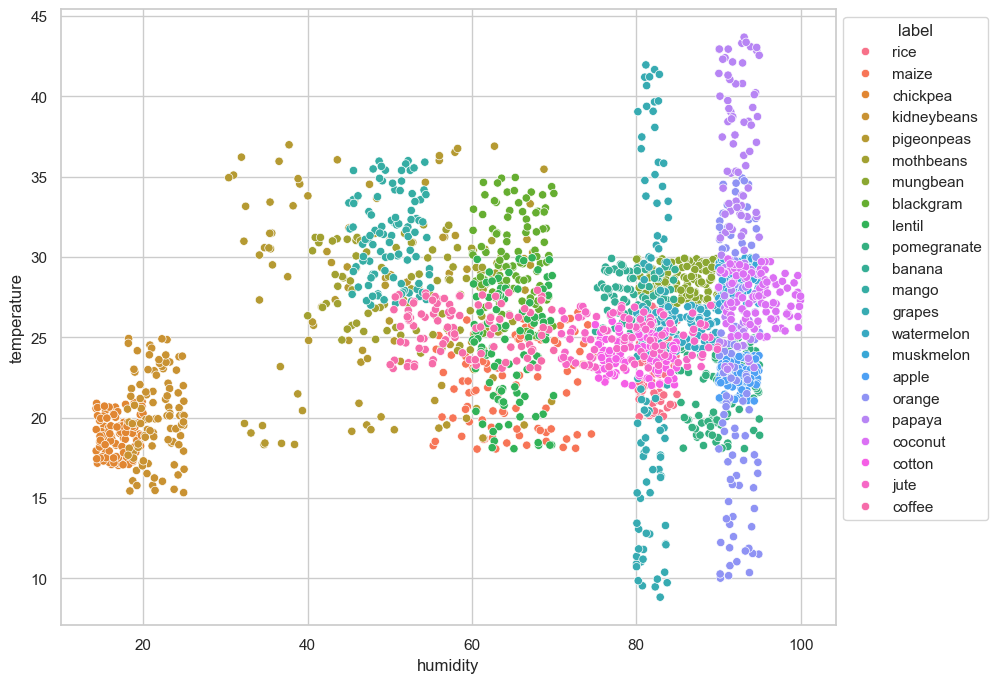

In [22]:
#Humidity VS Temperature
plt.figure(figsize=(10,8))
ax = sns.scatterplot(x='humidity',y='temperature',data=df,hue='label')
sns.move_legend(ax,"upper left", bbox_to_anchor=(1,1))
plt.show()

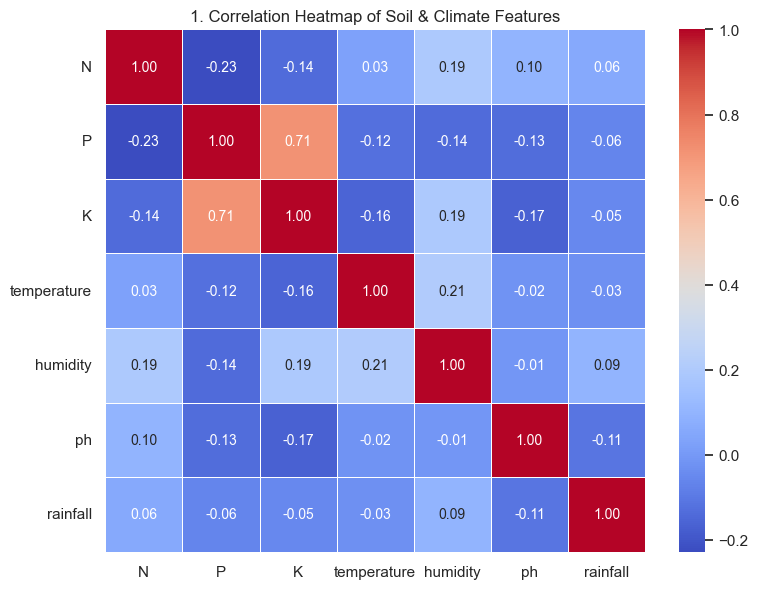

In [12]:
# Chart 1: Feature Correlation Heatmap
plt.figure(figsize=(8, 6))
numeric_df = df.drop(columns=['label'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('1. Correlation Heatmap of Soil & Climate Features')
plt.tight_layout()
plt.savefig('chart_1_correlation.png')
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_6464\3368891319.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_n.values[:10], y=avg_n.index[:10], palette='Greens_r')


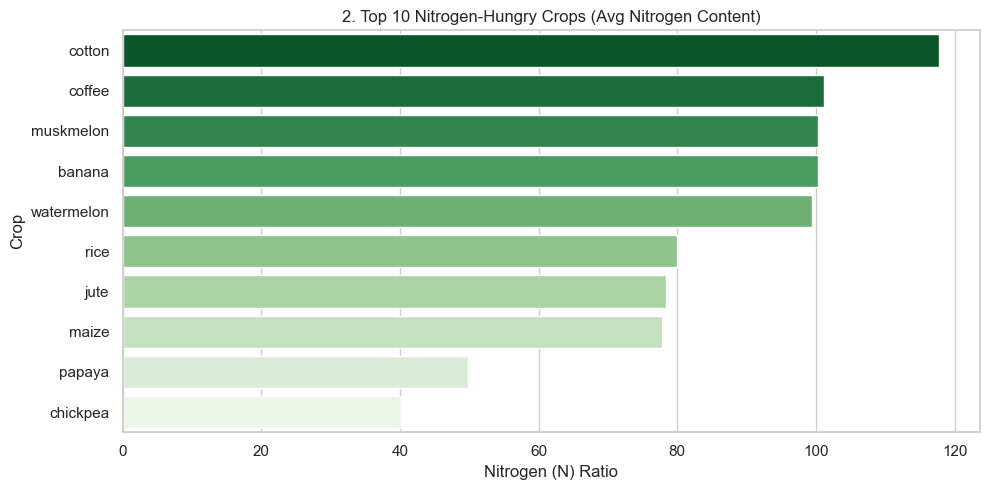

In [13]:
# Chart 2: Top 10 Nitrogen-Demanding Crops
plt.figure(figsize=(10, 5))
avg_n = df.groupby('label')['N'].mean().sort_values(ascending=False)
sns.barplot(x=avg_n.values[:10], y=avg_n.index[:10], palette='Greens_r')
plt.title('2. Top 10 Nitrogen-Hungry Crops (Avg Nitrogen Content)')
plt.xlabel('Nitrogen (N) Ratio')
plt.ylabel('Crop')
plt.tight_layout()
plt.savefig('chart_2_nitrogen.png')
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_6464\1344496718.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_k.values[:10], y=avg_k.index[:10], palette='Oranges_r')


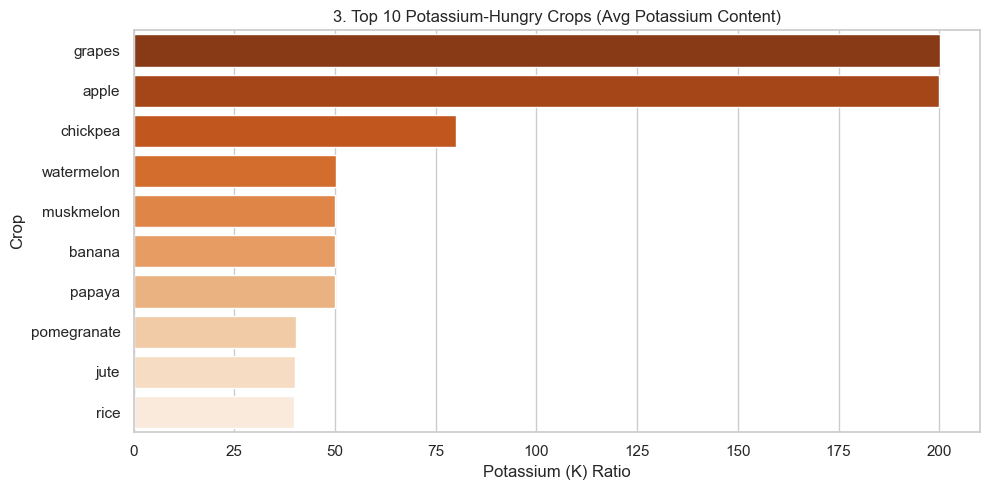

In [14]:
# Chart 3: Top 10 Potassium-Demanding Crops
plt.figure(figsize=(10, 5))
avg_k = df.groupby('label')['K'].mean().sort_values(ascending=False)
sns.barplot(x=avg_k.values[:10], y=avg_k.index[:10], palette='Oranges_r')
plt.title('3. Top 10 Potassium-Hungry Crops (Avg Potassium Content)')
plt.xlabel('Potassium (K) Ratio')
plt.ylabel('Crop')
plt.tight_layout()
plt.savefig('chart_3_potassium.png')
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_6464\3262124430.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_p.values[:10], y=avg_p.index[:10], palette='Blues_r')


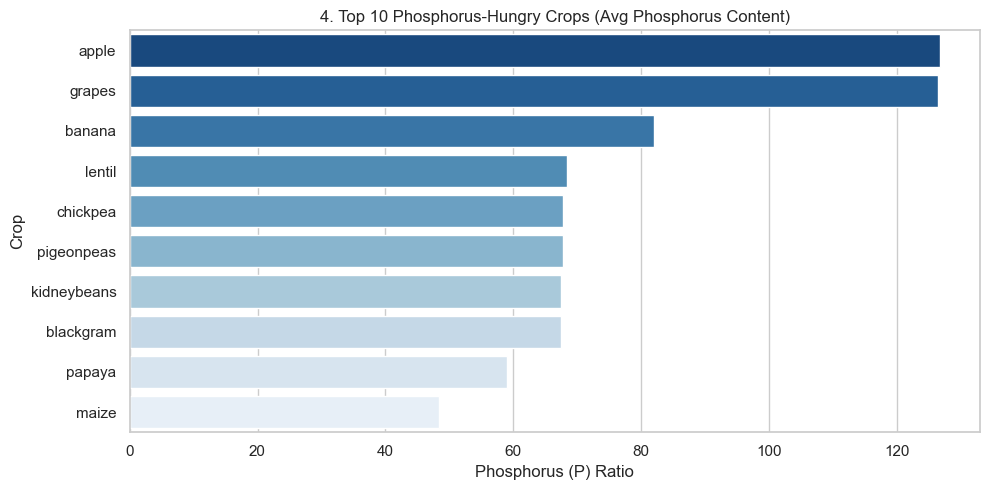

In [15]:
# Chart 4: Top 10 Phosphorus-Demanding Crops
plt.figure(figsize=(10, 5))
avg_p = df.groupby('label')['P'].mean().sort_values(ascending=False)
sns.barplot(x=avg_p.values[:10], y=avg_p.index[:10], palette='Blues_r')
plt.title('4. Top 10 Phosphorus-Hungry Crops (Avg Phosphorus Content)')
plt.xlabel('Phosphorus (P) Ratio')
plt.ylabel('Crop')
plt.tight_layout()
plt.savefig('chart_4_phosphorus.png')
plt.show()

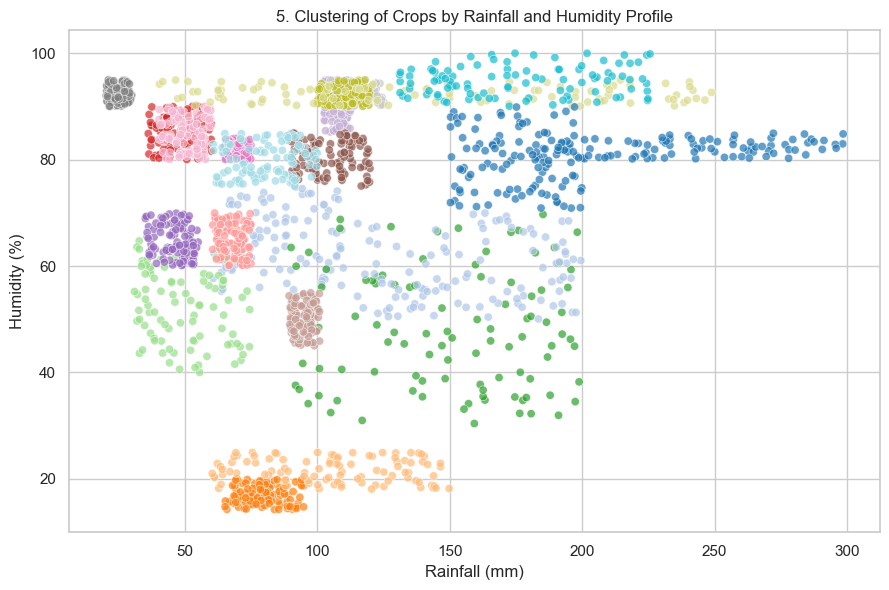

In [16]:
# Chart 5: Rainfall vs. Humidity Clustering Across Crops
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='rainfall', y='humidity', hue='label', legend=False, alpha=0.7, palette='tab20')
plt.title('5. Clustering of Crops by Rainfall and Humidity Profile')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Humidity (%)')
plt.tight_layout()
plt.savefig('chart_5_rainfall_humidity.png')
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_6464\2631345321.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_temp, x='temperature', y='label', palette='YlOrRd')


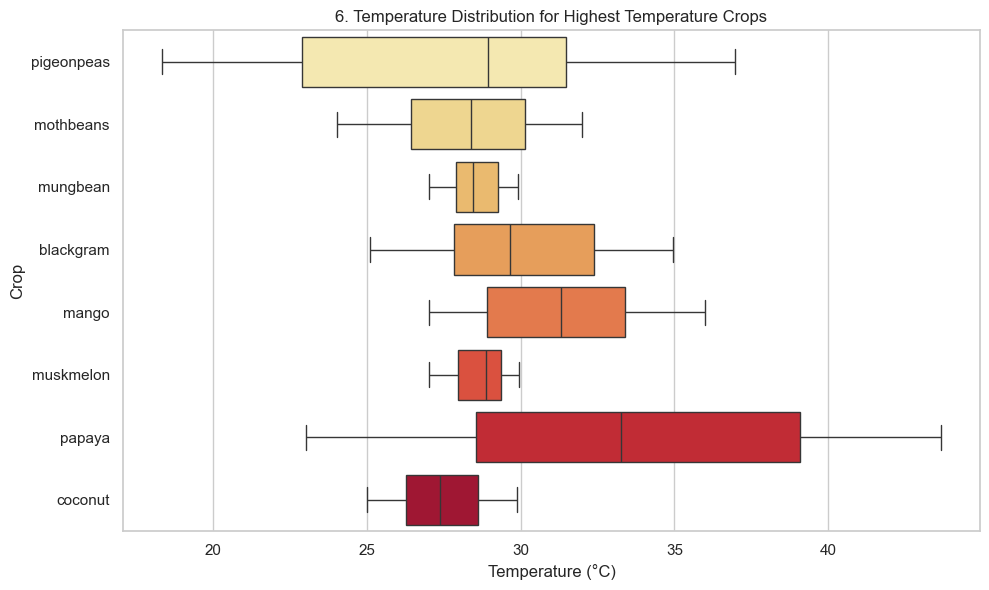

In [17]:
# Chart 6: Temperature Distribution for High-Temp Crops
plt.figure(figsize=(10, 6))
top_temp_crops = df.groupby('label')['temperature'].mean().sort_values(ascending=False).index[:8]
df_temp = df[df['label'].isin(top_temp_crops)]
sns.boxplot(data=df_temp, x='temperature', y='label', palette='YlOrRd')
plt.title('6. Temperature Distribution for Highest Temperature Crops')
plt.xlabel('Temperature (°C)')
plt.ylabel('Crop')
plt.tight_layout()
plt.savefig('chart_6_temperature.png')
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_6464\1287075390.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['label'].isin(selected_crops)], x='ph', y='label', palette='vlag')


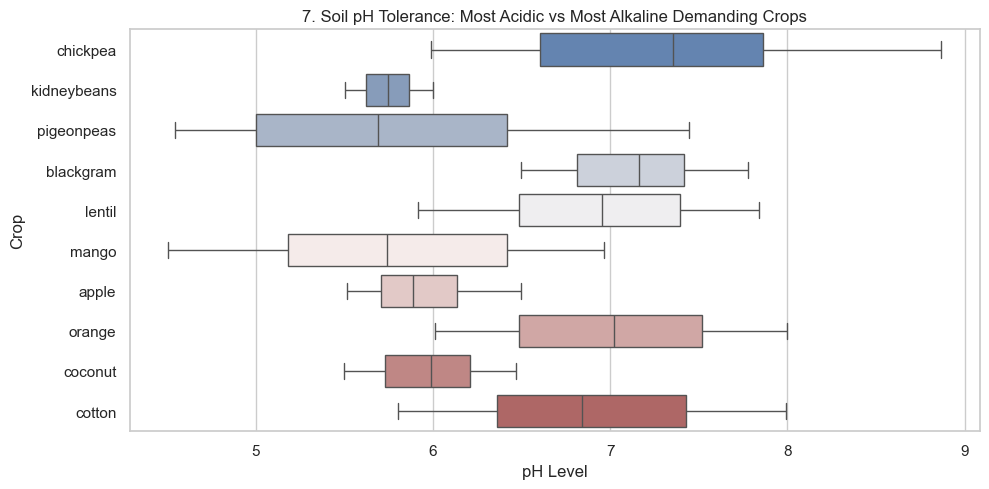

In [18]:
# Chart 7: Soil pH Tolerance across Select Crops
plt.figure(figsize=(10, 5))
ph_order = df.groupby('label')['ph'].mean().sort_values().index
selected_crops = ph_order[:5].tolist() + ph_order[-5:].tolist()
sns.boxplot(data=df[df['label'].isin(selected_crops)], x='ph', y='label', palette='vlag')
plt.title('7. Soil pH Tolerance: Most Acidic vs Most Alkaline Demanding Crops')
plt.xlabel('pH Level')
plt.ylabel('Crop')
plt.tight_layout()
plt.savefig('chart_7_ph.png')
plt.show()

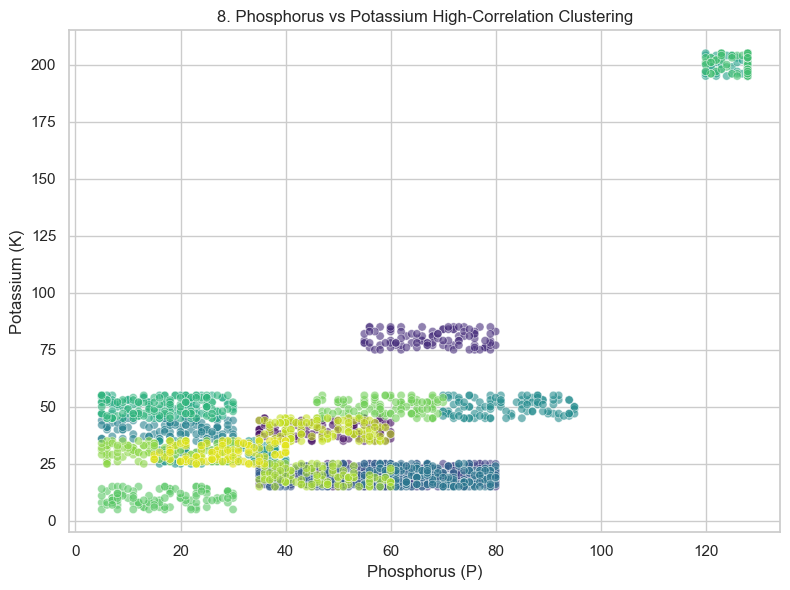

In [19]:
# Chart 8: Phosphorus vs Potassium High-Correlation Clustering
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='P', y='K', hue='label', alpha=0.6, palette='viridis', legend=False)
plt.title('8. Phosphorus vs Potassium High-Correlation Clustering')
plt.xlabel('Phosphorus (P)')
plt.ylabel('Potassium (K)')
plt.tight_layout()
plt.savefig('chart_8_pk_cluster.png')
plt.show()

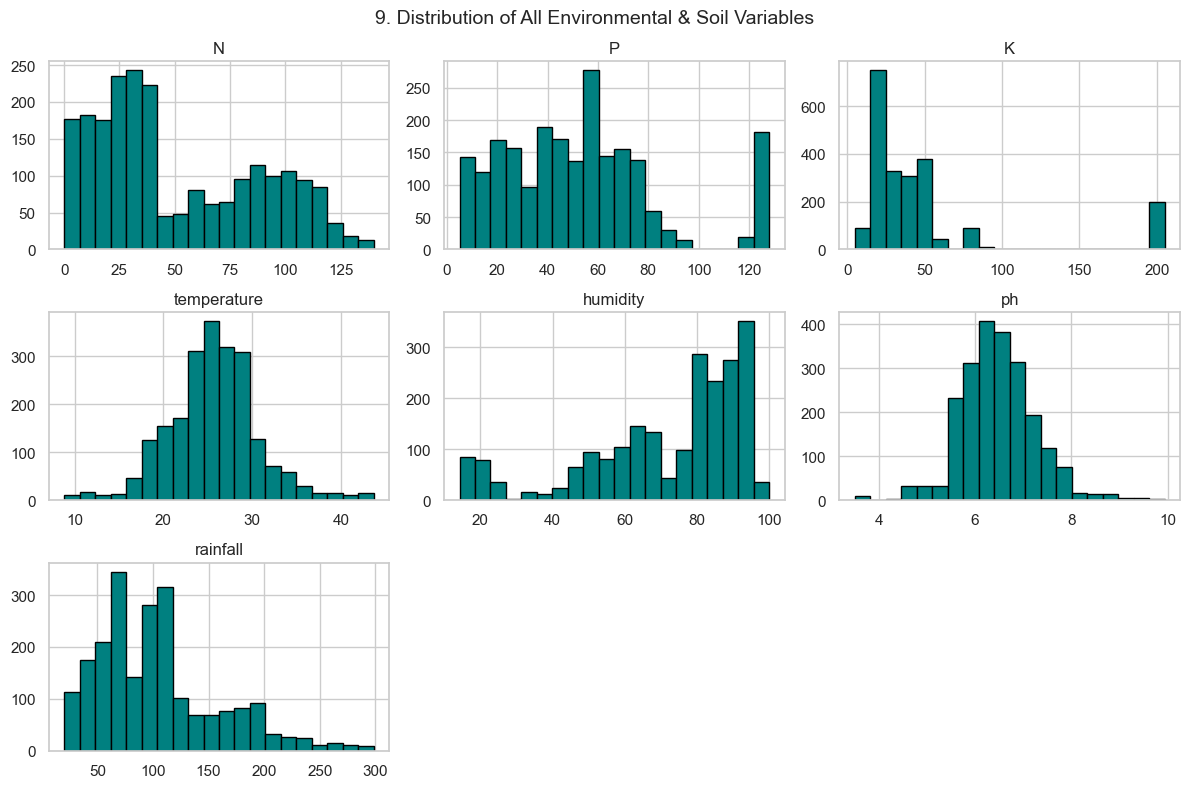

In [20]:

# Chart 9: Distribution of All Environmental & Soil Variables
df.drop(columns=['label']).hist(figsize=(12, 8), bins=20, color='teal', edgecolor='black')
plt.suptitle('9. Distribution of All Environmental & Soil Variables', fontsize=14)
plt.tight_layout()
plt.savefig('chart_9_distributions.png')
plt.show()


C:\Users\DELL\AppData\Local\Temp\ipykernel_6464\3029926148.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_rain.values[:10], y=avg_rain.index[:10], palette='Blues_d')


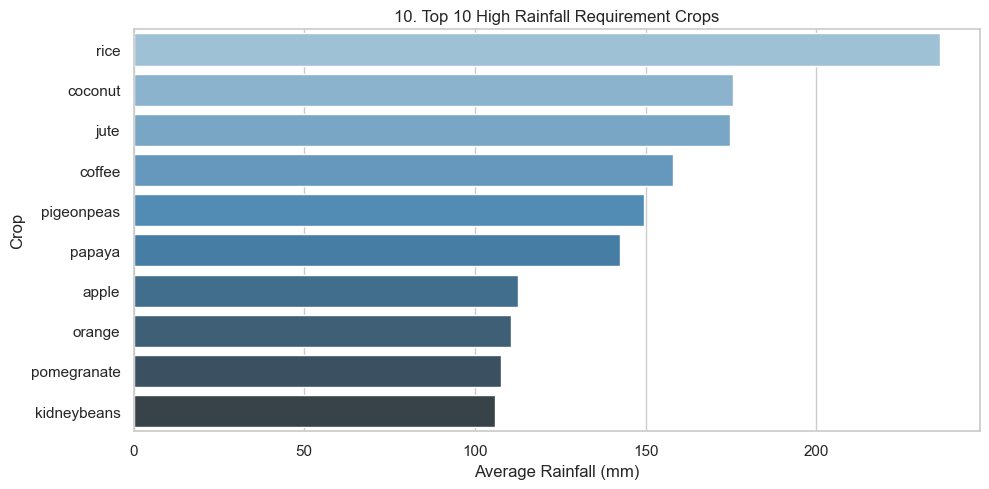

In [21]:
# Chart 10: Top High-Rainfall Requirement Crops
plt.figure(figsize=(10, 5))
avg_rain = df.groupby('label')['rainfall'].mean().sort_values(ascending=False)
sns.barplot(x=avg_rain.values[:10], y=avg_rain.index[:10], palette='Blues_d')
plt.title('10. Top 10 High Rainfall Requirement Crops')
plt.xlabel('Average Rainfall (mm)')
plt.ylabel('Crop')
plt.tight_layout()
plt.savefig('chart_10_rainfall_crops.png')
plt.show()
